In [ ]:
import pandas as pd
df = pd.read_csv("/content/boston.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
x=df.drop('MEDV',axis=1)
y=df['MEDV']
y

,MEDV
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2
...,...
501,22.4
502,20.6
503,23.9
504,22.0


In [ ]:
import numpy as np
x=np.array(x)
y=np.array(y).reshape(-1,1)

In [ ]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
from sklearn.linear_model import RidgeCV
alphas=np.logspace(-4,5,100)
ridge_cv=RidgeCV(alphas=alphas,cv=10)
ridge_cv.fit(x_train,y_train)
print("Best alpha:",ridge_cv.alpha_)

Best alpha: 10.0


In [ ]:
best_ridge=Ridge(alpha=ridge_cv.alpha_)
best_ridge.fit(x_train,y_train)
y_pred=best_ridge.predict(x_test)
y_pred

array([28.77409619, 35.58641713, 15.65318591, 24.93759439, 18.7316578 ,
       23.27614695, 17.84867323, 14.63909754, 22.57921063, 20.79505554,
       24.68829818, 18.9673638 , -5.62275979, 21.93240446, 19.29627413,
       25.90430497, 19.95158995,  5.82571391, 39.98921423, 17.59960509,
       26.93976547, 29.57142456, 11.78075453, 24.23582415, 17.74872943,
       15.50479611, 22.80551488, 14.74251484, 22.46986525, 19.40457223,
       22.24446989, 25.22093452, 25.76787542, 17.57173203, 16.51304049,
       17.34483952, 31.2404489 , 20.18884165, 23.82973222, 24.586258  ,
       14.22615657, 31.57728148, 41.83263604, 17.6661138 , 27.26586856,
       16.83325903, 14.3712001 , 25.8514816 , 20.01837325, 30.12684333,
       21.49684958, 33.91513136, 16.40164943, 26.37569126, 39.11868125,
       22.37666323, 18.79889319, 32.08154346, 25.09289264, 13.28060246,
       22.87113691, 30.28171318, 31.14335584, 16.11065699, 21.16028606,
       16.80186872, 20.3781559 , 25.87176072, 30.20197946, 11.69

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
rmse=np.sqrt(mse)
print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("R2 Score:",r2)

Mean Squared Error: 24.495845619667417
Root Mean Squared Error: 4.949327794728029
R2 Score: 0.6659677905050339


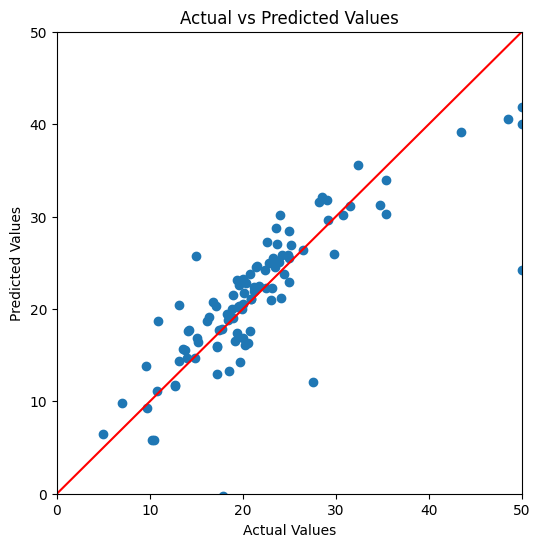

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred)
max_val=max(y_test.max(),y_pred.max())
plt.plot([0,max_val],[0,max_val],color='red')
plt.xlim(0,max_val)
plt.ylim(0,max_val)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score
y_pred=lr.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
rmse=np.sqrt(mse)
print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("R2 Score:",r2)

Mean Squared Error: 24.29111947497352
Root Mean Squared Error: 4.928602182665337
R2 Score: 0.668759493535632


In [ ]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=100, gamma=0.1)
svr.fit(x_train, y_train.ravel())

SVR(C=100, gamma=0.1)

In [ ]:
y_pred = svr.predict(x_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MSE : 12.55194537288986
RMSE: 3.542872474827433
R²  : 0.8288381584589917
